In [40]:
import pandas as pd

### 1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.

Используем данные из Predict Diabetes https://www.kaggle.com/datasets/whenamancodes/predict-diabities?resource=download

In [41]:
data = pd.read_csv('diabetes.csv', sep=",")

In [42]:
# размер набора данных
data.shape

(768, 9)

In [43]:
# типы колонок
data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

### 2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.

In [44]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [45]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.

Целевая переменная здесь — Outcome (0 — нет диабета, 1 — есть диабет).

In [46]:
from sklearn.model_selection import train_test_split

# Признаки
X = data.drop('Outcome', axis=1)

# Целевая переменная
y = data['Outcome']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% данных для тестирования
    random_state=42,    # фиксируем случайность
    stratify=y          # сохраняем соотношение классов
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

Размер обучающей выборки: (537, 8)
Размер тестовой выборки: (231, 8)
Размер y_train: (537,)
Размер y_test: (231,)


### 4. Обучите следующие модели:

#### Одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);

Тут классификация, поэтому использую логистическую регрессию

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Создание и обучение модели
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Предсказание
y_pred_lr = lr_model.predict(X_test)

# Метрики
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Accuracy =", acc_lr)
print("F1-score =", f1_lr)

print(classification_report(y_test, y_pred_lr))

Accuracy = 0.7402597402597403
F1-score = 0.5833333333333334
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       150
           1       0.67      0.52      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



Accuracy показывает долю правильных ответов модели. Модель правильно определила диабет или его отсутствие примерно у 74% пациентов.

F1-score — это баланс между Precision и Recall для положительного класса (Outcome = 1). Модель довольно посредственно распознаёт пациентов с диабетом.

Модель логистической регрессии показывает удовлетворительное качество классификации с точностью 74%. При этом модель лучше распознаёт пациентов без диабета (F1 = 0.81), чем пациентов с диабетом (F1 = 0.58). Низкое значение Recall для класса 1 (0.52) указывает на то, что значительная часть больных диабетом не выявляется моделью, что является критичным в медицинской задаче.

#### SVM

In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [49]:
#Обучение модели SVM

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [50]:
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Accuracy =", acc_svm)
print("F1-score =", f1_svm)

print(classification_report(y_test, y_pred_svm))

Accuracy = 0.7445887445887446
F1-score = 0.549618320610687
              precision    recall  f1-score   support

           0       0.75      0.91      0.82       150
           1       0.72      0.44      0.55        81

    accuracy                           0.74       231
   macro avg       0.74      0.68      0.69       231
weighted avg       0.74      0.74      0.73       231



Метод опорных векторов (SVM) был использован для решения задачи бинарной классификации наличия диабета.
Перед обучением данные были нормализованы, так как SVM чувствителен к масштабу признаков.

На тестовой выборке модель показала Accuracy = 0.745 и F1-score = 0.549 .

Полученные результаты свидетельствуют о том, что SVM обеспечивает сопоставимое качество по сравнению с логистической регрессией.
Особенно важно значение F1-score, так как оно отражает баланс между точностью и полнотой выявления пациентов с диабетом

#### Дерево решений

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Accuracy =", accuracy_score(y_test, y_pred_tree))
print("F1-score =", f1_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy = 0.7619047619047619
F1-score = 0.6206896551724138
              precision    recall  f1-score   support

           0       0.78      0.87      0.83       150
           1       0.70      0.56      0.62        81

    accuracy                           0.76       231
   macro avg       0.74      0.71      0.72       231
weighted avg       0.76      0.76      0.75       231



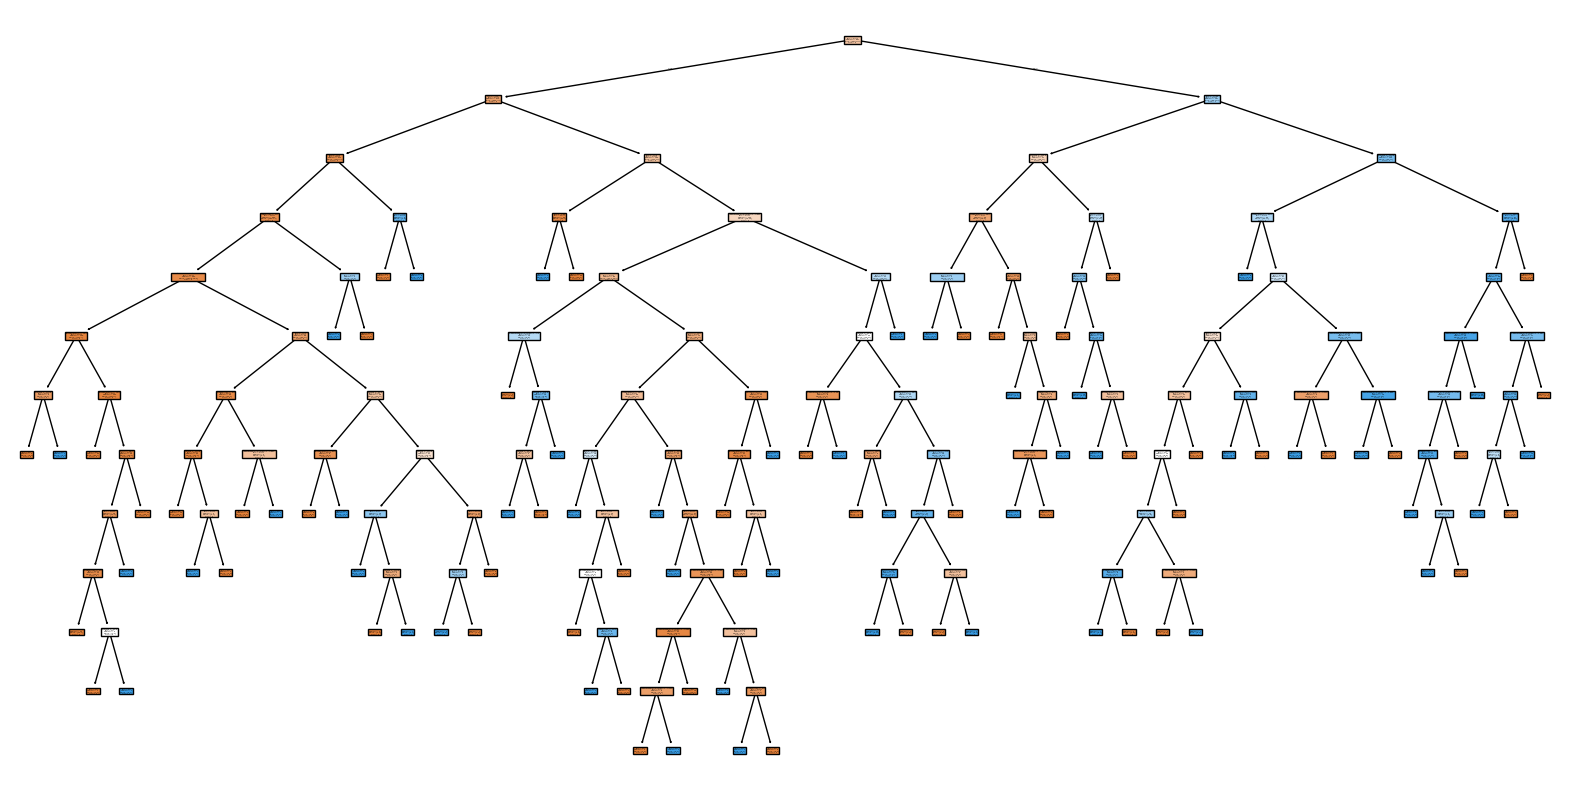

In [52]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X.columns, class_names=["0","1"], filled=True)
plt.show()

### 5. Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.

In [58]:
# Логистическая регрессия
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# SVM
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# Дерево решений
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

# Таблица сравнения
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree"],
    "Accuracy": [acc_lr, acc_svm, acc_tree],
    "F1-score": [f1_lr, f1_svm, f1_tree]
})

print(results)

                 Model  Accuracy  F1-score
0  Logistic Regression  0.740260  0.583333
1                  SVM  0.744589  0.549618
2        Decision Tree  0.761905  0.620690


In [61]:
### 6. Постройте график, показывающий важность признаков в дереве решений.

In [60]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    feature  importance
1                   Glucose    0.328421
5                       BMI    0.163325
6  DiabetesPedigreeFunction    0.153186
7                       Age    0.100319
2             BloodPressure    0.099709
0               Pregnancies    0.079542
4                   Insulin    0.046130
3             SkinThickness    0.029368


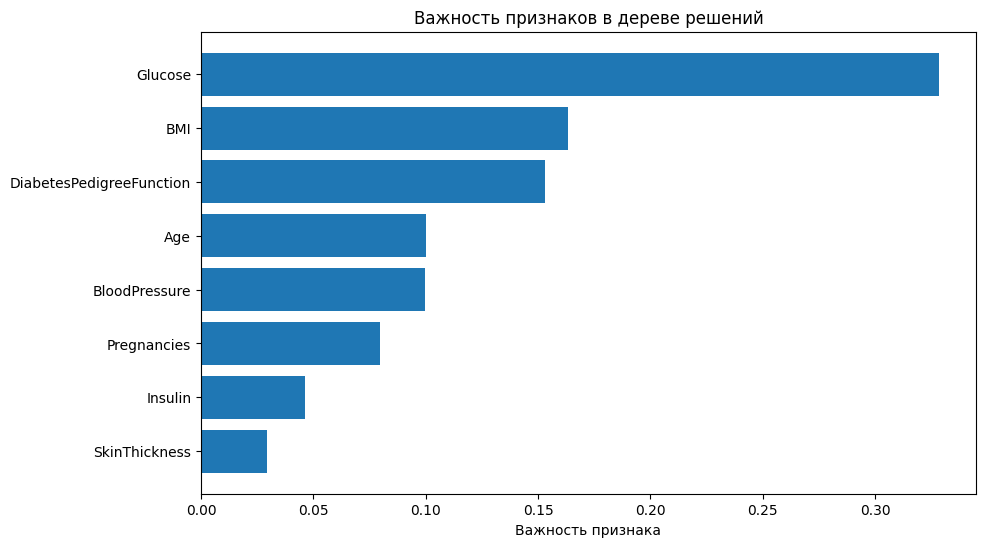

In [59]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tree_model.feature_importances_
}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel("Важность признака")
plt.title("Важность признаков в дереве решений")
plt.show()

### 7. Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

In [65]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(200,100))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True
)
plt.title("Дерево решений")
plt.show()

In [63]:
from sklearn.tree import export_text

rules = export_text(tree_model, feature_names=list(X.columns))
print(rules)

|--- Glucose <= 132.50
|   |--- Age <= 29.50
|   |   |--- BMI <= 45.40
|   |   |   |--- Pregnancies <= 7.50
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.51
|   |   |   |   |   |--- BloodPressure <= 19.00
|   |   |   |   |   |   |--- Glucose <= 116.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Glucose >  116.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- BloodPressure >  19.00
|   |   |   |   |   |   |--- BloodPressure <= 73.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- BloodPressure >  73.00
|   |   |   |   |   |   |   |--- Insulin <= 38.00
|   |   |   |   |   |   |   |   |--- Insulin <= 34.00
|   |   |   |   |   |   |   |   |   |--- Pregnancies <= 2.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- Pregnancies >  2.50
|   |   |   |   |   |   |   |   |   |   |--- Glucose <= 96.00
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   | 